# Entraîner un réseau de neurones convolutif (CNN) avec Weli

Ce notebook construit, entraîne et évalue un petit CNN pour reconnaître des chiffres manuscrits (0 à 9).

Les images viennent du jeu `load_digits` de scikit-learn : 1797 images de 8×8 pixels en niveaux de gris, intégrées à scikit-learn, donc **aucun téléchargement n'est nécessaire**.

Installation si besoin : `pip install weli-ml scikit-learn matplotlib`

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_digits

from weli.layers import Conv2D, MaxPool2D, Flatten, Dense, Dropout
from weli.losses import CategoricalCrossEntropy
from weli.models import Sequential, load_model
from weli.optimizers import Adam

np.random.seed(42)

## 1. Préparer les données

Les convolutions de Weli attendent des images au format `(batch, hauteur, largeur, canaux)`. On ajoute donc un canal de taille 1 et on ramène les pixels dans `[0, 1]`.

Les cibles sont encodées en **one-hot** : c'est le format attendu par `CategoricalCrossEntropy`,.

In [2]:
digits = load_digits()

X = (digits.images[..., np.newaxis] / 16.0).astype(np.float64)
labels = digits.target
Y = np.eye(10)[labels]

print("X :", X.shape, "| valeurs entre", X.min(), "et", X.max())
print("Y :", Y.shape)

X : (1797, 8, 8, 1) | valeurs entre 0.0 et 1.0
Y : (1797, 10)


## 2. Séparer entraînement, validation et test

On mélange les données avec une graine fixe, puis on les découpe en 70 % / 15 % / 15 %.

In [3]:
indices = np.random.permutation(len(X))
X, Y, labels = X[indices], Y[indices], labels[indices]

n_train = int(0.70 * len(X))
n_validation = int(0.15 * len(X))

x_train, y_train = X[:n_train], Y[:n_train]
x_validation, y_validation = X[n_train:n_train + n_validation], Y[n_train:n_train + n_validation]
x_test, y_test = X[n_train + n_validation:], Y[n_train + n_validation:]
labels_test = labels[n_train + n_validation:]

print("Entraînement :", x_train.shape, y_train.shape)
print("Validation  :", x_validation.shape, y_validation.shape)
print("Test        :", x_test.shape, y_test.shape)

Entraînement : (1257, 8, 8, 1) (1257, 10)
Validation  : (269, 8, 8, 1) (269, 10)
Test        : (271, 8, 8, 1) (271, 10)


## 3. Construire le CNN

L'architecture est classique : deux blocs `Conv2D → MaxPool2D`, puis une partie dense pour la classification.

La dernière couche `Dense(10)` renvoie des **logits** (scores non normalisés). La normalisation softmax est intégrée dans la perte avec `from_logits=True`.

In [4]:
model = Sequential([
    Conv2D(16, kernel_size=3, padding='same', activation='relu'),
    MaxPool2D(pool_size=2),
    Conv2D(32, kernel_size=3, padding='same', activation='relu'),
    MaxPool2D(pool_size=2),
    Flatten(),
    Dense(64, activation='relu'),
    Dropout(0.3),
    Dense(10),
], name="DigitsCNN")

## 4. Compiler le modèle

On choisit la fonction de perte et l'optimiseur. `input_shape` est donné sans la dimension batch.

In [5]:
loss_fn = CategoricalCrossEntropy(from_logits=True)
optimizer = Adam(lr=0.001)

model.compile(input_shape=(8, 8, 1), loss_fn=loss_fn, optimizer=optimizer)

model.summary()

Model: DigitsCNN
Layer (type)         Output Shape         Param #   
Conv2D (Conv2D)      (None, 8, 8, 16)     160       
MaxPool2D (MaxPool2D) (None, 4, 4, 16)     0         
Conv2D (Conv2D)      (None, 4, 4, 32)     4640      
MaxPool2D (MaxPool2D) (None, 2, 2, 32)     0         
Flatten (Flatten)    (None, np.int64(128)) 0         
Dense (Dense)        (None, 64)           8256      
Dropout (Dropout)    None                 0         
Dense (Dense)        (None, 10)           650       
Total params: 13706
Trainable params: 13706
Non-trainable params: 0
Input shape: (8, 8, 1)
Output shape: (10,)


## 5. Entraîner le modèle

Une époque parcourt tout l'ensemble d'entraînement par mini-batches de 32 images. La validation est calculée à chaque époque sur des données que le modèle n'apprend pas.

In [6]:
x_train = np.asarray(x_train, dtype=np.float64)
x_test = np.asarray(x_test, dtype=np.float64)
y_train = np.asarray(y_train, dtype=np.float64)
y_test = np.asarray(y_test, dtype=np.float64)

In [7]:
x_validation = np.asarray(x_validation, dtype=np.float64)
y_validation = np.asarray(y_validation, dtype=np.float64)

history = model.fit(
    x_train,
    y_train,
    epochs=15,
    batch_size=32,
    validation_data=(x_validation, y_validation),
    verbose=1,
)

Epoch 1/15 - loss: 2.3182 - acc: 0.2154 - val_loss: 1.8257 - val_acc: 0.4613
Epoch 2/15 - loss: 1.5521 - acc: 0.5420 - val_loss: 1.1019 - val_acc: 0.8806
Epoch 3/15 - loss: 1.0541 - acc: 0.7073 - val_loss: 0.6878 - val_acc: 0.9030
Epoch 4/15 - loss: 0.7170 - acc: 0.8054 - val_loss: 0.4366 - val_acc: 0.9308
Epoch 5/15 - loss: 0.5254 - acc: 0.8683 - val_loss: 0.3284 - val_acc: 0.9498
Epoch 6/15 - loss: 0.4616 - acc: 0.8664 - val_loss: 0.2631 - val_acc: 0.9498
Epoch 7/15 - loss: 0.3968 - acc: 0.8816 - val_loss: 0.2090 - val_acc: 0.9602
Epoch 8/15 - loss: 0.3095 - acc: 0.9102 - val_loss: 0.1902 - val_acc: 0.9567
Epoch 9/15 - loss: 0.2592 - acc: 0.9305 - val_loss: 0.1698 - val_acc: 0.9482
Epoch 10/15 - loss: 0.2261 - acc: 0.9316 - val_loss: 0.1423 - val_acc: 0.9637
Epoch 11/15 - loss: 0.1992 - acc: 0.9477 - val_loss: 0.1490 - val_acc: 0.9586
Epoch 12/15 - loss: 0.1950 - acc: 0.9508 - val_loss: 0.1251 - val_acc: 0.9706
Epoch 13/15 - loss: 0.1642 - acc: 0.9570 - val_loss: 0.1257 - val_acc: 0.

## 6. Suivre l'apprentissage

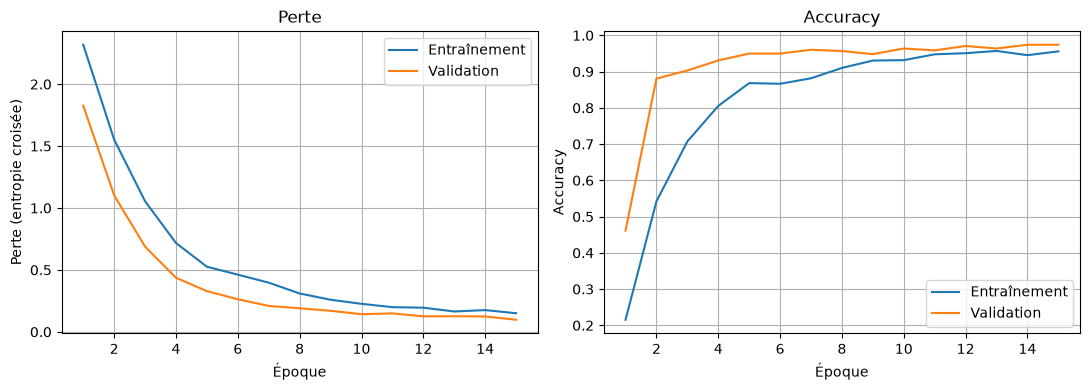

In [8]:
epochs = range(1, len(history["train_loss"]) + 1)

fig, (ax_loss, ax_acc) = plt.subplots(1, 2, figsize=(11, 4))

ax_loss.plot(epochs, history["train_loss"], label="Entraînement")
ax_loss.plot(epochs, history["val_loss"], label="Validation")
ax_loss.set(xlabel="Époque", ylabel="Perte (entropie croisée)", title="Perte")

ax_acc.plot(epochs, history["train_acc"], label="Entraînement")
ax_acc.plot(epochs, history["val_acc"], label="Validation")
ax_acc.set(xlabel="Époque", ylabel="Accuracy", title="Accuracy")

for ax in (ax_loss, ax_acc):
    ax.legend()
    ax.grid(True)

plt.tight_layout()
plt.show()

## 7. Évaluer sur le jeu de test

Le jeu de test n'a servi ni à l'entraînement ni à la validation : c'est la mesure la plus honnête des performances.

In [9]:
test_loss, test_acc = model.evaluate(x_test, y_test, loss_fn, batch_size=32)
print(f"Test - perte : {test_loss:.4f} | accuracy : {test_acc:.2%}")

logits = model.predict(x_test)
predicted = logits.argmax(axis=1)
print(f"Accuracy calculée directement : {(predicted == labels_test).mean():.2%}")

Test - perte : 0.1044 | accuracy : 95.79%
Accuracy calculée directement : 95.94%


## 8. Visualiser quelques prédictions

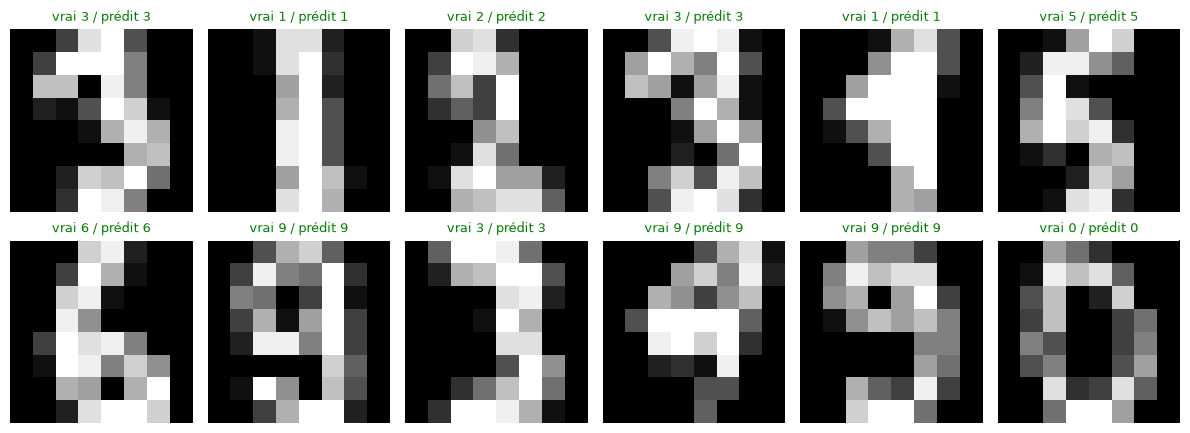

In [10]:
fig, axes = plt.subplots(2, 6, figsize=(12, 4.5))

for ax, image, true_label, predicted_label in zip(axes.ravel(), x_test, labels_test, predicted):
    ax.imshow(image[..., 0], cmap="gray")
    ax.set_title(
        f"vrai {true_label} / prédit {predicted_label}",
        color="green" if true_label == predicted_label else "red",
        fontsize=9,
    )
    ax.axis("off")

plt.tight_layout()
plt.show()

## 9. Sauvegarder et recharger le modèle

On sauvegarde l'architecture et les poids, puis on recharge le modèle.

Le modèle rechargé donne exactement les mêmes prédictions.

In [ ]:
MODEL_PATH = "digits_cnn.weli"
model.save(MODEL_PATH)

reloaded = load_model(MODEL_PATH)
same_predictions = np.allclose(model.predict(x_test), reloaded.predict(x_test))
print("Prédictions identiques après rechargement :", same_predictions)

## Pour aller plus loin

- Ajouter `BatchNorm2D` après les convolutions pour stabiliser l'entraînement.
- Augmenter le nombre d'époques ou la largeur des couches (`Conv2D(64, ...)`).
- Essayer une autre loi d'optimisation (`SGD`, `RMSprop`) depuis `weli.optimizers`.
- Utiliser un modèle pré-construit : `weli.models.resnet18` (attention : entrée 224×224, lourd en calcul avec NumPy).